In [1]:
import numpy as np
from jax import numpy as jnp
import jax
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, AnharmonicOscillator
from blueprint.devices import Device

import os, math

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update('jax_default_device', jax.devices('cuda')[1])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update('jax_enable_x64', False) # Simple
# dtype = jnp.complex64

# TODO:
- Get rid of caching (eigvals and eigkets)
- Fix time dependent term: support arg instead of kwarg
- Add Pauli Transfer Matrix construction
- Find the optimal or good enough free pulse params to do a good CZ
- Loss
- Metrics
- Make things run fine on cluster
- Add data type explicitely

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms, s = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi, 1e9 * 2 * math.pi

## Qubits

In [3]:
label = "Q1"
charging_energy = 0.17874386390652913 * GHz
josephson_energy = 28.045385714769342 * GHz
asymmetry = 0.617379794210013
charge_cutoff = 100
offset_charge = 0.0
ext_flux = 0.0
dim = 3

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
    relax_time=None,
    deph_time=None,
)
transmon.diagonalize(dim)

label = "Q2"
charging_energy = 0.1706758643430758 * GHz
josephson_energy = 27.770515104169455 * GHz
asymmetry = 0.5487079408012716
charge_cutoff = 100
offset_charge = 0.0
ext_flux = math.pi / 2
dim = 3

other_transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
    relax_time=None,
    deph_time=None,
)
other_transmon.diagonalize(dim)

In [4]:
print(transmon.get_hamiltonian())
print(other_transmon.get_hamiltonian())

[[ 0.          0.          0.        ]
 [ 0.          6.14852788  0.        ]
 [ 0.          0.         12.10523746]]
[[0.         0.         0.        ]
 [0.         4.38356101 0.        ]
 [0.         0.         8.57897919]]


## Device

In [5]:
device = Device([transmon, other_transmon])
g0 = (
    7 * MHz
    / float(transmon.charge_zpf)
    / float(other_transmon.charge_zpf)
)
device.add_capacative_coupling(
    qubits=("Q1", "Q2"),
    label="C_Q1_Q2",
    prefactor=g0,
)
device.index_eigenstates()

In [6]:
print(device.get_hamiltonian())

[[-2.60384539e-34-1.59786300e-49j -1.40104443e-18+2.44816402e-35j
  -2.07927884e-34-8.60717160e-36j  1.30095216e-18+7.98335927e-34j
   7.00000000e-03-1.22316950e-19j  1.03886441e-18+4.30037764e-20j
  -2.48267237e-34-1.52350456e-49j -1.33584517e-18+2.33423582e-35j
  -1.98251714e-34-8.20662671e-36j]
 [-1.40104443e-18-2.44816402e-35j  4.38356101e+00+4.72629806e-49j
  -1.93796126e-18-2.99792090e-35j  7.00000000e-03+1.22316950e-19j
  -1.94463819e-17-2.36138739e-33j  9.68258292e-03+1.49784303e-19j
  -1.33584517e-18-2.33423582e-35j  3.71105077e-33+4.50635420e-49j
  -1.84777595e-18-2.85840912e-35j]
 [-2.85359789e-34+8.60717160e-36j -1.93796126e-18+2.99792090e-35j
   8.57897919e+00-1.48511093e-48j  1.42573532e-18-4.30037764e-20j
   9.68258292e-03-1.49784303e-19j  1.54532536e-17+7.42001917e-33j
  -2.72080234e-34+8.20662671e-36j -1.84777595e-18+2.85840912e-35j
  -2.94902203e-33-1.41599954e-48j]
 [ 1.30095216e-18+7.98335927e-34j  7.00000000e-03-1.22316950e-19j
   1.03886441e-18+4.30037764e-20j  6.

In [7]:
print(device.get_int_hamiltonian()[jnp.abs(device.get_int_hamiltonian())>1e-8].real)

[0.007      0.007      0.00968258 0.00968258 0.007      0.00974279
 0.007      0.00968258 0.00974279 0.01347649 0.00968258 0.01347649
 0.00974279 0.00974279 0.01347649 0.01347649]


In [8]:
device.is_diagonalized

False

## Drives

### Flux drives

In [9]:
from blueprint.pulses import flux_pulses, coupler_pulses

In [10]:
device["Q1"].add_flux_drive(
    label='flux_Q1_cz_Q1_Q2', flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)
device["Q2"].add_flux_drive(
    label="flux_Q2_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)

In [11]:
0.8 / 0.255, 0.8 / 0.4163522432365655

(3.1372549019607843, 1.9214499573272414)

In [12]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843, #9.817191999999999,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

device["Q2"].drives["flux_Q2_cz_Q1_Q2"].set_params(
    hold_first_voltage=0.4163522432365655,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=1.9214499573272414, #9.90753,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

### Coupler drive v2

In [13]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.net_zero_transition_coupling_pulse
)

In [14]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    off_coupling=g0,
    on_coupling=g0 + 20 * MHz,
    # on_coupling=g0 + (9 / math.sqrt(2)) * MHz,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    gaussian_filter_sigma=0.5,
    transition_coupling=None,
)

In [90]:
g0

0.0035736420719793796

## Function to build `Hfull: dq.TimeDependentArray` from a device  

In [50]:
import dynamiqs as dq
from jax import Array
from blueprint.base.terms import Numeric

In [51]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for qubit in device.qubits:
        drives_iterator = qubit.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            print(dq_func(t=0.0))
            print(dq_func(t=40.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )

    for coupling_label, coupling in device._couplings.items():
        drives_iterator = coupling.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            # print(prefactor.free_params)
            print(dq_func(t=0.0))
            print(dq_func(t=40.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )
    return dq_hamiltonian

In [52]:
full_hamiltonian = build_dynamiqs_hamiltonian(device=device)

0.0
-8.505977321060394
0.0
-20.118528264116254
0.0
-19.92134815739315
0.0
-8.422610909067794
0.0
0.019999999999999997


In [53]:
full_hamiltonian(0.0)

Array([[-2.60384539e-34-1.59786300e-49j, -1.40104443e-18+2.44816402e-35j,
        -2.07927884e-34-8.60717160e-36j,  1.30095216e-18+7.98335927e-34j,
         7.00000000e-03-1.22316950e-19j,  1.03886441e-18+4.30037764e-20j,
        -2.48267237e-34-1.52350456e-49j, -1.33584517e-18+2.33423582e-35j,
        -1.98251714e-34-8.20662671e-36j],
       [-1.40104443e-18-2.44816402e-35j,  4.38356101e+00+4.72629806e-49j,
        -1.93796126e-18-2.99792090e-35j,  7.00000000e-03+1.22316950e-19j,
        -1.94463819e-17-2.36138739e-33j,  9.68258292e-03+1.49784303e-19j,
        -1.33584517e-18-2.33423582e-35j,  3.71105077e-33+4.50635420e-49j,
        -1.84777595e-18-2.85840912e-35j],
       [-2.85359789e-34+8.60717160e-36j, -1.93796126e-18+2.99792090e-35j,
         8.57897919e+00-1.48511093e-48j,  1.42573532e-18-4.30037764e-20j,
         9.68258292e-03-1.49784303e-19j,  1.54532536e-17+7.42001917e-33j,
        -2.72080234e-34+8.20662671e-36j, -1.84777595e-18+2.85840912e-35j,
        -2.94902203e-33-1.41

In [54]:
full_hamiltonian(t=20.0).shape

(9, 9)

In [55]:
jnp.allclose(full_hamiltonian(0.0), device.get_hamiltonian())

Array(True, dtype=bool)

In [56]:
import qutip

In [57]:
qutip.Qobj(np.array(full_hamiltonian(0.0)))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[-2.60384539e-34-1.59786300e-49j -1.40104443e-18+2.44816402e-35j
  -2.07927884e-34-8.60717160e-36j  1.30095216e-18+7.98335927e-34j
   7.00000000e-03-1.22316950e-19j  1.03886441e-18+4.30037764e-20j
  -2.48267237e-34-1.52350456e-49j -1.33584517e-18+2.33423582e-35j
  -1.98251714e-34-8.20662671e-36j]
 [-1.40104443e-18-2.44816402e-35j  4.38356101e+00+4.72629806e-49j
  -1.93796126e-18-2.99792090e-35j  7.00000000e-03+1.22316950e-19j
  -1.94463819e-17-2.36138739e-33j  9.68258292e-03+1.49784303e-19j
  -1.33584517e-18-2.33423582e-35j  3.71105077e-33+4.50635420e-49j
  -1.84777595e-18-2.85840912e-35j]
 [-2.85359789e-34+8.60717160e-36j -1.93796126e-18+2.99792090e-35j
   8.57897919e+00-1.48511093e-48j  1.42573532e-18-4.30037764e-20j
   9.68258292e-03-1.49784303e-19j  1.54532536e-17+7.42001917e-33j
  -2.72080234e-34+8.20662671e-36j -1.84777595e-18+2.85840912e-35j
  -2.94902203e-33-1.41599954e-48j]
 [ 1.30095216

In [58]:
qutip.Qobj(np.array(full_hamiltonian(40.0)))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[ 3.73734348e-02-1.11834877e-19j -1.21583106e-17+7.28867125e-03j
   2.05089795e-03+8.79602361e-18j  4.47501468e-18-6.42869671e-03j
   4.41475100e-02-7.71426968e-19j  6.55189668e-18+2.71215664e-19j
   1.56030032e-03+1.64861771e-18j -8.42489114e-18+1.47215284e-34j
  -1.25033136e-33-5.17574478e-35j]
 [-1.18282290e-17-7.28867125e-03j  4.41793579e+00-6.47140111e-19j
  -1.28915112e-17+9.64916532e-03j  4.41475100e-02+7.71426968e-19j
  -1.26374005e-16-6.42869671e-03j  6.10659894e-02+9.44657717e-19j
  -8.42489114e-18-1.47215284e-34j  1.56030032e-03+1.64861771e-18j
  -1.16535296e-17-1.80273778e-34j]
 [ 2.05089795e-03-8.31192781e-18j -1.53095282e-17-9.64916532e-03j
   8.61034121e+00-1.40578049e-19j  8.99180916e-18-2.71215664e-19j
   6.10659894e-02-9.44657717e-19j  9.37305673e-17-6.42869671e-03j
  -1.71595212e-33+5.17574478e-35j -1.16535296e-17+1.80273778e-34j
   1.56030032e-03+1.64861771e-18j]
 [ 2.76451368

# Eigenenergies vs. time

In [59]:
from jax import scipy as jsp

In [60]:
# === tsave
tsave = jnp.linspace(0, 100, 101)

In [61]:
all_eigvals = []
for t in tsave:
    _hamil = full_hamiltonian(t)
    eig_vals, eig_vecs = jsp.linalg.eigh(_hamil, eigvals_only=False)
    norm_vals = eig_vals - eig_vals[0]
    all_eigvals.append(norm_vals)
all_eigvals = jnp.array(all_eigvals)

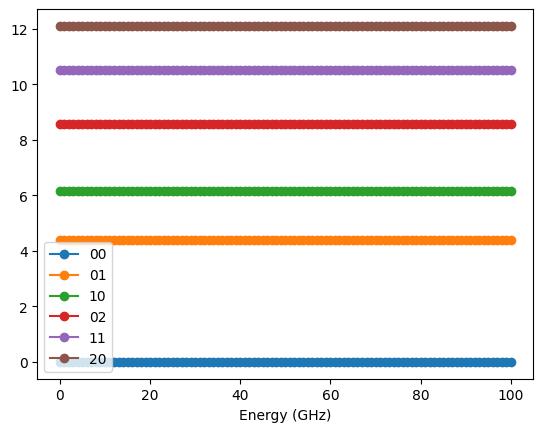

In [62]:
plt.plot(tsave, all_eigvals[:, 0], '-o', label='00')
plt.plot(tsave, all_eigvals[:, 1], "-o", label="01")
plt.plot(tsave, all_eigvals[:, 2], "-o", label="10")
plt.plot(tsave, all_eigvals[:, 3], "-o", label="02")
plt.plot(tsave, all_eigvals[:, 4], "-o", label="11")
plt.plot(tsave, all_eigvals[:, 5], "-o", label="20")
plt.legend()
plt.xlabel("Time (ns)")
plt.xlabel("Energy (GHz)")
plt.show()

# dynamiqs

In [63]:
import time

In [64]:
# === initial states
psi0 = jnp.stack([
    device.get_eigenstate(0, 0)[1][:, None], 
    device.get_eigenstate(0, 1)[1][:, None],
    device.get_eigenstate(1, 0)[1][:, None],
    device.get_eigenstate(1, 1)[1][:, None],
])
psi0.shape

(4, 9, 1)

In [65]:
# === tsave
tsave = jnp.linspace(0, 100, 101)

In [66]:
# === run mesolve
t0 = time.time()
result = dq.mesolve(
    full_hamiltonian,
    jump_ops=[jnp.zeros((device.dim, device.dim))],
    rho0=psi0,
    tsave=tsave,
    # exp_ops=[],
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=100000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result)

Sim took 2.65 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (4, 101, 9, 9) | 511.31 Kb
Infos    : avg. 1308.0 steps (1292.5 accepted, 15.5 rejected) | infos shape (4,)


In [67]:
result.states.shape

(4, 101, 9, 9)

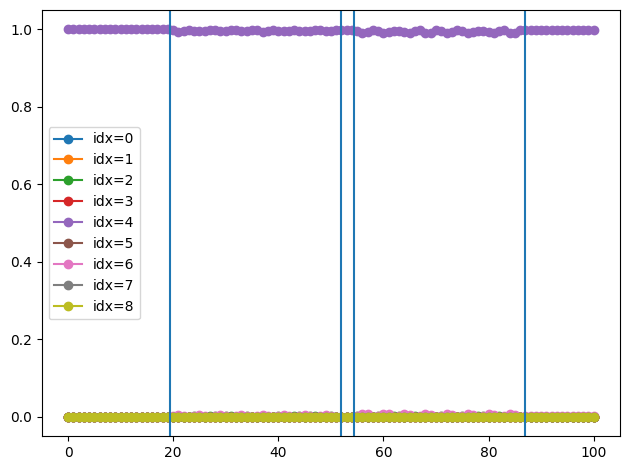

In [68]:
for idx in range(9):
    plt.plot(tsave, result.states[3, :, idx, idx].real, '-o', label=f'{idx=}')
plt.axvline(1.9349107142857144e1)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352)
plt.axvline(
    1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352 + 65.15 * 1 / 2
)
plt.legend()
plt.tight_layout()

In [69]:
device._eig_inds

Array([0, 1, 3, 2, 4, 6, 5, 7, 8], dtype=int64)

In [70]:
device.get_bare_hamiltonian().diagonal()

Array([ 0.        ,  4.38356101,  8.57897919,  6.14852788, 10.53208889,
       14.72750707, 12.10523746, 16.48879847, 20.68421664], dtype=float64)

# Transition frequencies vs. external flux plots

In [71]:
# Do something dumb here because of the caching, will fix and improve later
ext_fluxes = np.linspace(0, math.pi, 101)

charge_cutoff = 100
offset_charge = 0.0
dim = 3

charging_energy_1 = 0.17874386390652913 * GHz
josephson_energy_1 = 28.045385714769342 * GHz
asymmetry_1 = 0.617379794210013

energies_0_t1 = np.zeros(ext_fluxes.shape)
energies_1_t1 = np.zeros(ext_fluxes.shape)
energies_2_t1 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_1 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_1,
        josephson_energy=josephson_energy_1,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        asymmetry=asymmetry_1,
        relax_time=None,
        deph_time=None,
    )
    transmon_1.diagonalize(dim)
    energies_0_t1[idx] = 0.0  # transmon_1.get_freq_difference(0, 1)
    energies_1_t1[idx] = transmon_1.get_freq_difference(0, 1)
    energies_2_t1[idx] = transmon_1.get_freq_difference(0, 2)

charging_energy_2 = 0.1706758643430758 * GHz
josephson_energy_2 = 27.770515104169455 * GHz
asymmetry_2 = 0.5487079408012716

energies_0_t2 = np.zeros(ext_fluxes.shape)
energies_1_t2 = np.zeros(ext_fluxes.shape)
energies_2_t2 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_2 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_2,
        josephson_energy=josephson_energy_2,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        asymmetry=asymmetry_2,
        relax_time=None,
        deph_time=None,
    )
    transmon_2.diagonalize(dim)
    energies_0_t2[idx] = 0.0  # transmon_1.get_freq_difference(0, 1)
    energies_1_t2[idx] = transmon_2.get_freq_difference(0, 1)
    energies_2_t2[idx] = transmon_2.get_freq_difference(0, 2)

In [72]:
transmon_1._asymm

0.617379794210013

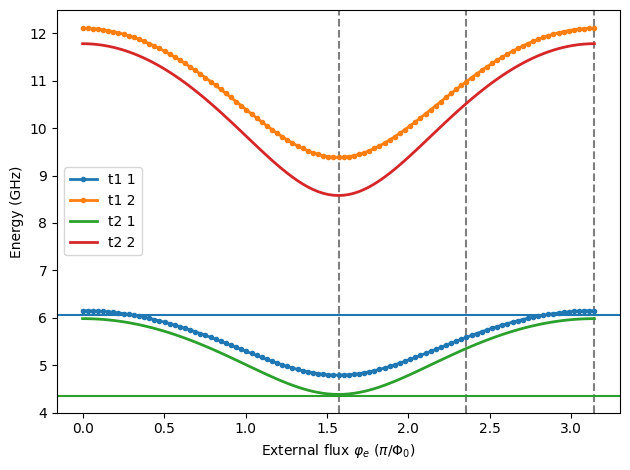

In [73]:
markers = ".-"
lw = 2.0
# plt.plot(ext_fluxes, energies_0_t1, markers, lw=lw, label=f"t1 0")
plt.plot(ext_fluxes, energies_1_t1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_2_t1, markers, lw=lw, label=f"t1 2")

markers = "-"
# plt.plot(ext_fluxes, energies_0_t2, markers, lw=lw, label=f"t2 0")
plt.plot(ext_fluxes, energies_1_t2, markers, lw=lw, label=f"t2 1")
plt.plot(ext_fluxes, energies_2_t2, markers, lw=lw, label=f"t2 2")

plt.axhline(6.067657949379383, ls="-", c="C0")
plt.axhline(4.344903495992916, ls="-", c="C2")

plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi * 3/4, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [74]:
effective_josephson_energies_1 = (
    josephson_energy_1 * abs(np.cos(ext_fluxes)) *
    np.sqrt(1 + asymmetry_1**2 * np.tan(ext_fluxes)**2)
)
frequencies_1 = (
    np.sqrt(8 * charging_energy_1 * abs(effective_josephson_energies_1))
    - charging_energy_1
)

effective_josephson_energies_2 = (
    josephson_energy_2
    * abs(np.cos(ext_fluxes))
    * np.sqrt(1 + asymmetry_2**2 * np.tan(ext_fluxes) ** 2)
)
frequencies_2 = (
    np.sqrt(8 * charging_energy_2 * abs(effective_josephson_energies_2))
    - charging_energy_2
)

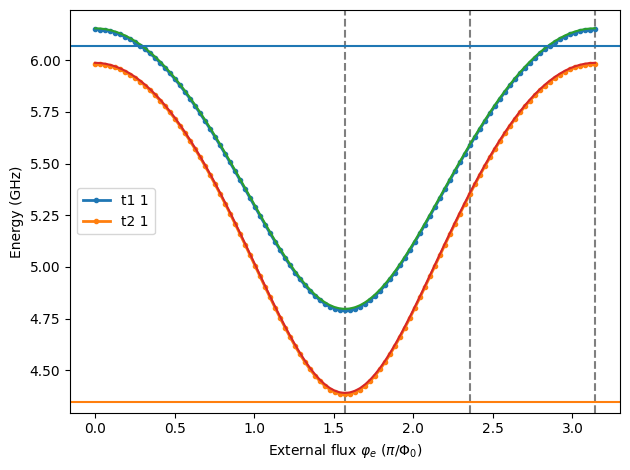

In [75]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_1_t1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_1_t2, markers, lw=lw, label=f"t2 1")

plt.plot(ext_fluxes, frequencies_1, "-")
plt.plot(ext_fluxes, frequencies_2, "-")

plt.axhline(6.067657949379383, ls="-", c="C0")
plt.axhline(4.344903495992916, ls="-", c="C1")

plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

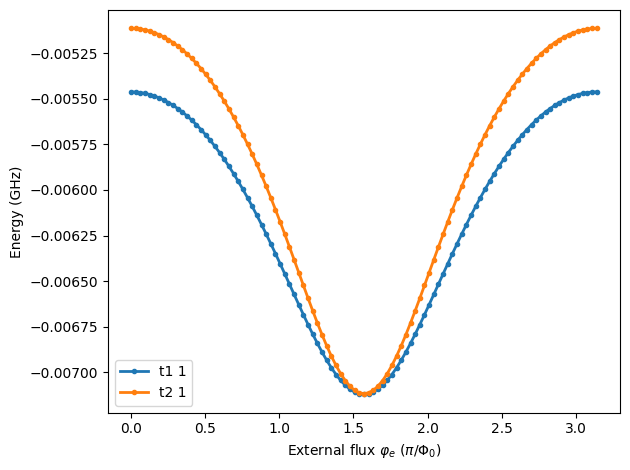

In [76]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_1_t1 - frequencies_1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_1_t2 - frequencies_2, markers, lw=lw, label=f"t2 1")

# plt.plot(ext_fluxes, frequencies_1, "-")
# plt.plot(ext_fluxes, frequencies_2, "-")

# plt.axhline(6.067657949379383, ls="-", c="C0")
# plt.axhline(4.344903495992916, ls="-", c="C1")

plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [77]:
.27 * math.pi

0.8482300164692442

In [78]:
# Do something dumb here because of the caching, will fix and improve later
ext_fluxes = np.linspace(0.23 * math.pi, 0.27 * math.pi, 101)

charge_cutoff = 100
offset_charge = 0.0
dim = 3

charging_energy_1 = 0.17874386390652913 * GHz
josephson_energy_1 = 28.045385714769342 * GHz
asymmetry_1 = 0.617379794210013

charging_energy_2 = 0.1706758643430758 * GHz
josephson_energy_2 = 27.770515104169455 * GHz
asymmetry_2 = 0.5487079408012716

energies_00 = np.zeros(ext_fluxes.shape)
energies_01 = np.zeros(ext_fluxes.shape)
energies_02 = np.zeros(ext_fluxes.shape)
energies_10 = np.zeros(ext_fluxes.shape)
energies_11 = np.zeros(ext_fluxes.shape)
energies_12 = np.zeros(ext_fluxes.shape)
energies_20 = np.zeros(ext_fluxes.shape)
energies_21 = np.zeros(ext_fluxes.shape)
energies_22 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_1 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_1,
        josephson_energy=josephson_energy_1,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        # ext_flux=0.0,
        asymmetry=asymmetry_1,
        relax_time=None,
        deph_time=None,
    )
    transmon_1.diagonalize(dim)
    transmon_2 = TunableTransmon(
        label="Q2",
        charging_energy=charging_energy_2,
        josephson_energy=josephson_energy_2,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        # ext_flux=math.pi / 2,
        ext_flux=ext_flux + math.pi / 2,
        asymmetry=asymmetry_2,
        relax_time=None,
        deph_time=None,
    )
    transmon_2.diagonalize(dim)
    device = Device([transmon_1, transmon_2])
    g0 = 7 * MHz / float(transmon_1.charge_zpf) / float(transmon_2.charge_zpf)
    device.add_capacative_coupling(
        qubits=("Q1", "Q2"),
        label="C_Q1_Q2",
        prefactor=g0,
    )
    device.index_eigenstates()
    energies_00[idx] = device.get_eigenstate(0, 0)[0]
    energies_01[idx] = device.get_eigenstate(0, 1)[0]
    energies_02[idx] = device.get_eigenstate(0, 2)[0]
    energies_10[idx] = device.get_eigenstate(1, 0)[0]
    energies_11[idx] = device.get_eigenstate(1, 1)[0]
    energies_12[idx] = device.get_eigenstate(1, 2)[0]
    energies_20[idx] = device.get_eigenstate(2, 0)[0]
    energies_21[idx] = device.get_eigenstate(2, 1)[0]
    energies_22[idx] = device.get_eigenstate(2, 2)[0]

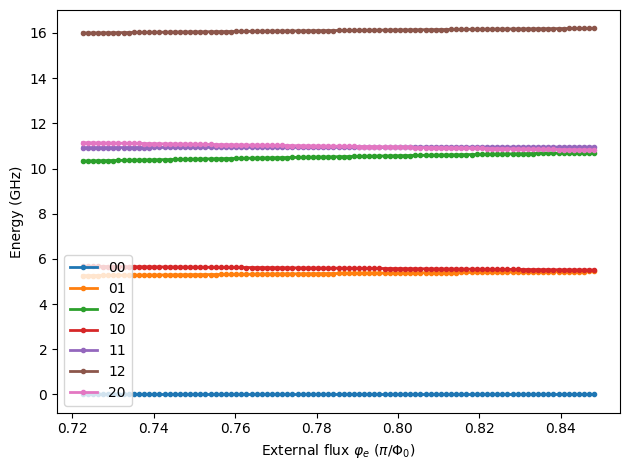

In [79]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

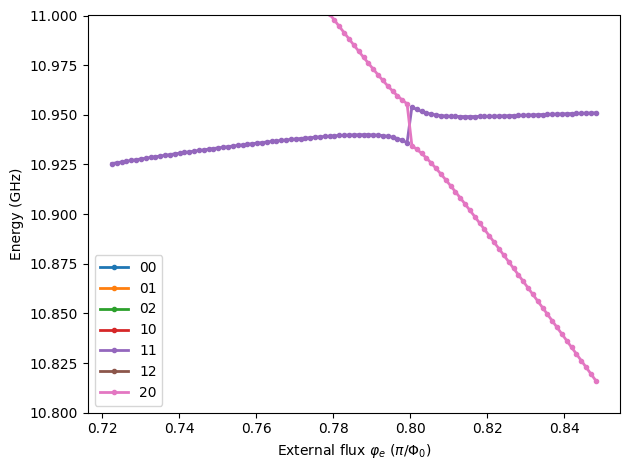

In [80]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.ylim([10.8, 11])
plt.tight_layout()

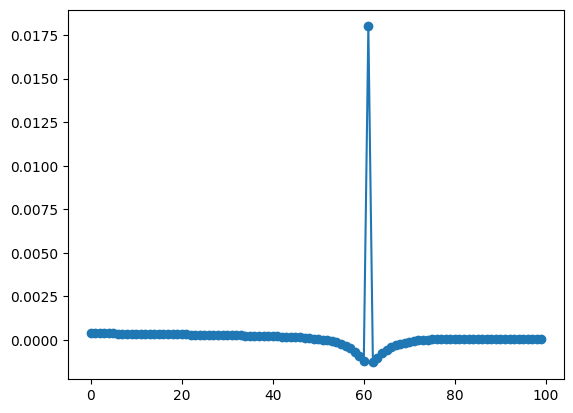

In [81]:
plt.plot(np.diff(energies_11), '-o')

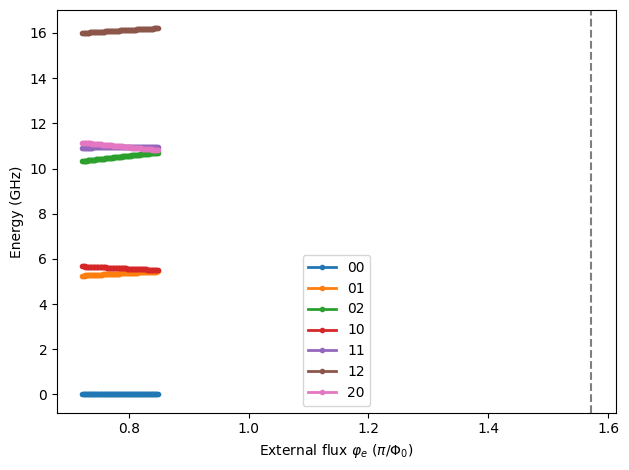

In [82]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [83]:
transmon_1.abs_anharmonicity

Array(-0.19356142, dtype=float64)

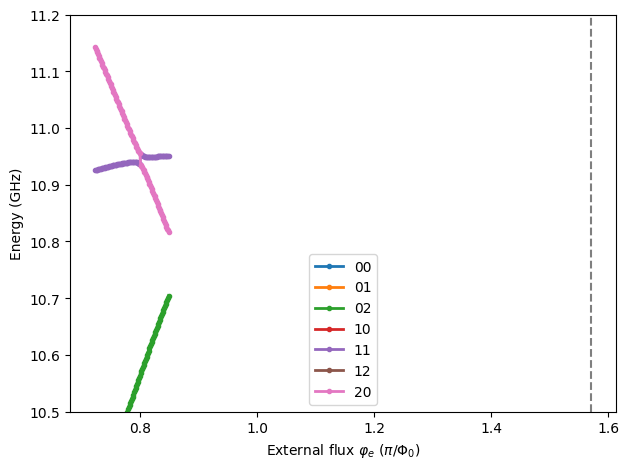

In [84]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.ylim([10.5, 11.2])
plt.tight_layout()

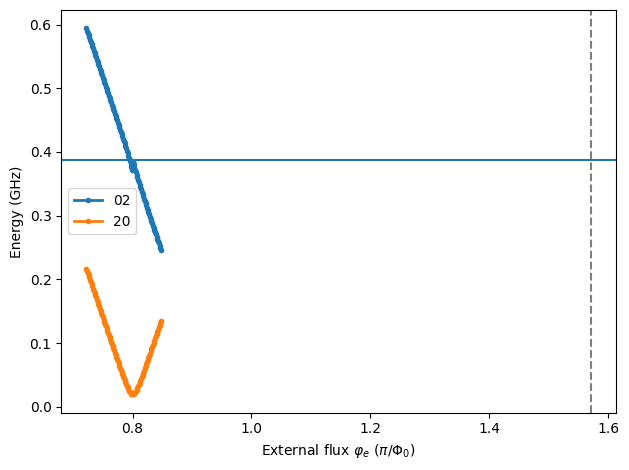

In [85]:
markers = ".-"
lw = 2.0
# plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
# plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes,np.abs(energies_11 - energies_02), markers, lw=lw, label=f"02")
# plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
# plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
# plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, np.abs(energies_11 - energies_20), markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.axhline(-2 * transmon_1.abs_anharmonicity)
# plt.ylim([10.5, 11.2])
plt.tight_layout()

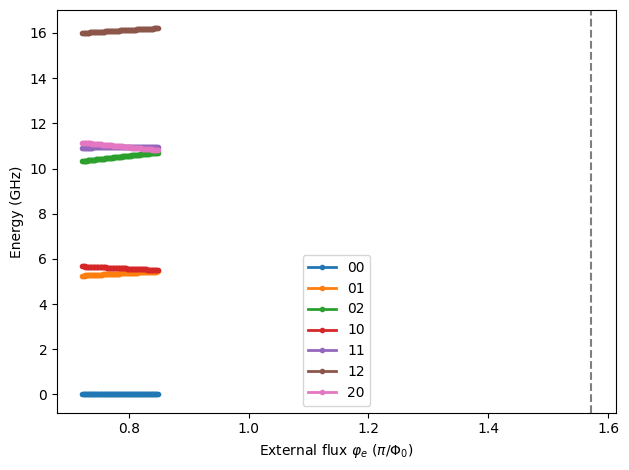

In [86]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

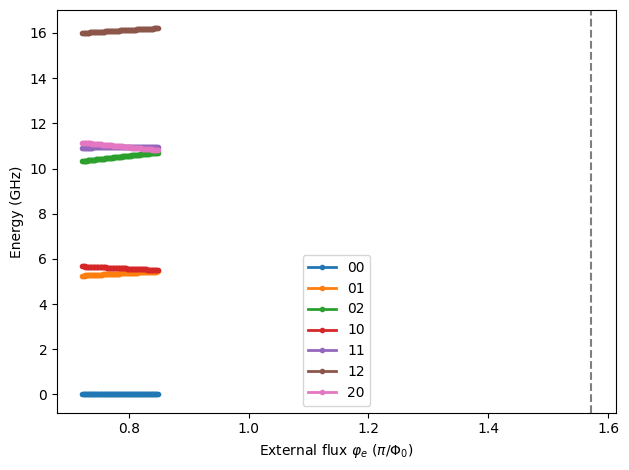

In [87]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [88]:
energies_00

array([-4.48482784e-06, -4.48466261e-06, -4.48449870e-06, -4.48433613e-06,
       -4.48417488e-06, -4.48401497e-06, -4.48385639e-06, -4.48369915e-06,
       -4.48354324e-06, -4.48338866e-06, -4.48323542e-06, -4.48308352e-06,
       -4.48293295e-06, -4.48278372e-06, -4.48263583e-06, -4.48248928e-06,
       -4.48234406e-06, -4.48220019e-06, -4.48205765e-06, -4.48191645e-06,
       -4.48177660e-06, -4.48163808e-06, -4.48150091e-06, -4.48136508e-06,
       -4.48123059e-06, -4.48109744e-06, -4.48096564e-06, -4.48083518e-06,
       -4.48070606e-06, -4.48057828e-06, -4.48045185e-06, -4.48032676e-06,
       -4.48020302e-06, -4.48008062e-06, -4.47995956e-06, -4.47983985e-06,
       -4.47972148e-06, -4.47960445e-06, -4.47948877e-06, -4.47937444e-06,
       -4.47926144e-06, -4.47914979e-06, -4.47903949e-06, -4.47893053e-06,
       -4.47882291e-06, -4.47871664e-06, -4.47861171e-06, -4.47850812e-06,
       -4.47840588e-06, -4.47830498e-06, -4.47820542e-06, -4.47810720e-06,
       -4.47801033e-06, -

In [89]:
170675864.3430758 / 1e9

0.1706758643430758

In [89]:
device.get_eigenstate(0, 0)

KeyboardInterrupt: 

# Drive plots

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
drives_list[0]

# OLD Coupler drive
Where we use the frequencies of both qubits at time t (getting the flux from NZT callables and approximating the freq from ext_flux) and the first-order perturbation theory expression for g(delta_1c, delta_2c)

In [ ]:
# device._couplings["C_Q1_Q2"].add_drive(
#     label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.capacitive_coupling_pulse
# )

In [ ]:
from typing import Callable
from functools import partial
from blueprint.base import QuantumSystem
from blueprint.qubits import TunableTransmon


def build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1: TunableTransmon,
    transmon_2: TunableTransmon,
    flux_drive_label_1: str,
    flux_drive_label_2: str,
    flux_callable_1: Callable = flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2: Callable = flux_pulses.net_zero_transition_flux_pulse,
):
    # Only use the params that are set (i.e. not None) in the Drive object.
    flux_drive_1 = transmon_1.drives[flux_drive_label_1]
    not_none_params_1 = {
        key: val for key, val in flux_drive_1.param_vals.items() if val is not None
    }
    partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)
    # Same for transmon 2
    flux_drive_2 = transmon_2.drives[flux_drive_label_2]
    not_none_params_2 = {
        key: val for key, val in flux_drive_2.param_vals.items() if val is not None
    }
    partial_func_flux_2 = partial(flux_callable_2, **not_none_params_2)

    return partial(
        coupler_pulses.capacitive_coupling_pulse,
        flux_drive_transmon_1=partial_func_flux_1,
        flux_drive_transmon_2=partial_func_flux_2,
        EJ_1=transmon_1._ej,
        EJ_2=transmon_2._ej,
        EC_1=transmon_1._ec,
        EC_2=transmon_2._ec,
        asymm_1=transmon_1._asymm,
        asymm_2=transmon_2._asymm,
        static_ext_flux_1=transmon_1._ext_flux,
        static_ext_flux_2=transmon_2._ext_flux,
    )

In [ ]:
# Only use the params that are set (i.e. not None) in the Drive object.
transmon_1 = device["Q1"]
flux_drive_label_1 = "flux_Q1_cz_Q1_Q2"
flux_callable_1 = flux_pulses.net_zero_transition_flux_pulse

flux_drive_1 = transmon_1.drives[flux_drive_label_1]
not_none_params_1 = {
    key: val for key, val in flux_drive_1.param_vals.items() if val is not None
}
partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)

In [ ]:
partial_func_flux_1(0.0)

In [ ]:
print(transmon._ext_flux)
print(other_transmon._ext_flux)

In [ ]:
coupler_pulse = build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1=device["Q1"],
    transmon_2=device["Q2"],
    flux_drive_label_1="flux_Q1_cz_Q1_Q2",
    flux_drive_label_2="flux_Q2_cz_Q1_Q2",
    flux_callable_1=flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2=flux_pulses.net_zero_transition_flux_pulse,
)

In [ ]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulse
)

In [ ]:
g0 = 7 * MHz / float(transmon.charge_zpf) / float(other_transmon.charge_zpf)
g0

In [ ]:
frequency_resonator=10.0 * GHz
omega_q1 = device["Q1"].fundamental_frequency
omega_q2 = device["Q2"].fundamental_frequency
delta_1 = abs(omega_q1 - frequency_resonator)
delta_2 = abs(omega_q2 - frequency_resonator)
coupling_to_res = math.sqrt(2 * g0 * delta_1 * delta_2 / (delta_1 + delta_2))
coupling_to_res

In [ ]:
coupling_to_res**2 / 2 * (1 / delta_1 + 1 / delta_2)

In [ ]:
g0

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    frequency_resonator=frequency_resonator,
    coupling_res_trans_1=coupling_to_res,
    coupling_res_trans_2=coupling_to_res,
)

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].eval_prefactors(t=0.0)

In [ ]:
for prefactor, operator in device._couplings["C_Q1_Q2"].get_drive_hamiltonian(
    decompose=True
):
    print(prefactor(t=0.0))
    print(operator)

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
device.get_int_hamiltonian()

In [ ]:
device["Q1"].fundamental_frequency

In [ ]:
def compute_freq(ext_flux, asymm, EJ, EC):
    # Do the `compute_eff_josephson_energy()` part
    cos_term = math.cos(ext_flux)
    sqrt_term = math.sqrt(1 + asymm**2 * math.tan(ext_flux) ** 2)
    EJ_effective_1 = EJ * abs(cos_term) * sqrt_term
    # Do the `ext_flux_to_approx_freq()` part
    frequency = math.sqrt(8 * EC * EJ_effective_1) - EC
    return frequency

compute_freq(
    device["Q1"]._ext_flux, device["Q1"]._asymm, device["Q1"]._ej, device["Q1"]._ec)